file di analisi per dead zones, dati simulati con G4

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import h5py
from pathlib import Path
import sys
sys.path.append('/home/matti/uni/lab/Lab-muons/Data/calibration')
from error_prop import propagazione_errore


RESULT_ROOT = Path('/home/matti/uni/lab/Lab-muons/simulazioni/tia/g4/results/mgp')


def result_path(folder, number):
    return (
        RESULT_ROOT / folder / f'{number}.h5',
        RESULT_ROOT / folder / f'run_{number}.h5',
    )


def count_hits(h5_paths, chunk_size=100_000):
    """Count detector coincidences from paired HDF5 files in chunks."""
    count_both = 0
    count_all_three = 0

    for h5_path in h5_paths:
        with h5py.File(h5_path, 'r') as file:
            data = file['data']
            row_count = len(data['HitBottom'])
            for start in range(0, row_count, chunk_size):
                stop = min(start + chunk_size, row_count)
                hit_bottom = data['HitBottom'][start:stop]
                hit_top = data['HitTop'][start:stop]
                hit_middle = data['HitMiddle'][start:stop]

                both = (hit_bottom == 1) & (hit_top == 1)
                all_three = both & (hit_middle == 1)
                count_both += int(both.sum())
                count_all_three += int(all_three.sum())

    return count_both, count_all_three


frac = lambda val: propagazione_errore(["a", "b"] , "a/b" , val , [[np.sqrt(val[0]) , 0] , [0 , np.sqrt(val[1])]] , Display=False)

# cos

In [2]:
mgp0_m = result_path('cos', 0)
mgp0_p = result_path('cos', 1)
mgp15_m = result_path('cos', 2)
mgp15_p = result_path('cos', 3)
mgp30_m = result_path('cos', 4)
mgp30_p = result_path('cos', 5)
mgp45_m = result_path('cos', 6)
mgp45_p = result_path('cos', 7)
mgp60_m = result_path('cos', 8)
mgp60_p = result_path('cos', 9)

In [3]:
d0m, t0m = count_hits(mgp0_m)
d0p, t0p = count_hits(mgp0_p)
d15m, t15m = count_hits(mgp15_m)
d15p, t15p = count_hits(mgp15_p)
d30m, t30m = count_hits(mgp30_m)
d30p, t30p = count_hits(mgp30_p)
d45m, t45m = count_hits(mgp45_m)
d45p, t45p = count_hits(mgp45_p)
d60m, t60m = count_hits(mgp60_m)
d60p, t60p = count_hits(mgp60_p)

In [4]:
print(d0m, t0m)

646806 645704


In [5]:
print(t0m/d0m, t0p/d0p)
print(t15m/d15m, t15p/d15p)
print(t30m/d30m, t30p/d30p)
print(t45m/d45m, t45p/d45p)
print(t60m/d60m, t60p/d60p)

0.9982962433867342 0.998198840590447
0.9466286070666123 0.9466607529501216
0.7880407022457401 0.7872691216823853
0.5768491403316506 0.5821201375648176
0.4979799754083963 0.501536975232742


# cos^2

In [6]:
mgp0_ms = result_path('cos_squared', 0)
mgp0_ps = result_path('cos_squared', 1)
mgp15_ms = result_path('cos_squared', 2)
mgp15_ps = result_path('cos_squared', 3)
mgp30_ms = result_path('cos_squared', 4)
mgp30_ps = result_path('cos_squared', 5)
mgp45_ms = result_path('cos_squared', 6)
mgp45_ps = result_path('cos_squared', 7)
mgp60_ms = result_path('cos_squared', 8)
mgp60_ps = result_path('cos_squared', 9)

In [7]:
d0ms, t0ms = count_hits(mgp0_ms)
d0ps, t0ps = count_hits(mgp0_ps)
d15ms, t15ms = count_hits(mgp15_ms)
d15ps, t15ps = count_hits(mgp15_ps)
d30ms, t30ms = count_hits(mgp30_ms)
d30ps, t30ps = count_hits(mgp30_ps)
d45ms, t45ms = count_hits(mgp45_ms)
d45ps, t45ps = count_hits(mgp45_ps)
d60ms, t60ms = count_hits(mgp60_ms)
d60ps, t60ps = count_hits(mgp60_ps)

In [8]:
print(t0ms/d0ms, t0ps/d0ps)
print(t15ms/d15ms, t15ps/d15ps)
print(t30ms/d30ms, t30ps/d30ps)
print(t45ms/d45ms, t45ps/d45ps)
print(t60ms/d60ms, t60ps/d60ps)
print(t60ms,d60ms, t60ps,d60ps)
print(t45ms,d45ms, t45ps,d45ps)

0.9987734932658096 0.9986738997747409
0.949227207181591 0.949756763434719
0.7848496398717207 0.7834236008534383
0.5491218764733616 0.552527600232423
0.5099975909419417 0.5092165898617511
6351 12453 6409 12586
18635 33936 19018 34420


# cos^1/3

In [9]:
mgp0_m1 = result_path('cos_1_3', 0)
mgp0_p1 = result_path('cos_1_3', 1)
mgp15_m1 = result_path('cos_1_3', 2)
mgp15_p1 = result_path('cos_1_3', 3)
mgp30_m1 = result_path('cos_1_3', 4)
mgp30_p1 = result_path('cos_1_3', 5)
mgp45_m1 = result_path('cos_1_3', 6)
mgp45_p1 = result_path('cos_1_3', 7)
mgp60_m1 = result_path('cos_1_3', 8)
mgp60_p1 = result_path('cos_1_3', 9)

In [10]:
d0m1, t0m1 = count_hits(mgp0_m1)
d0p1, t0p1 = count_hits(mgp0_p1)
d15m1, t15m1 = count_hits(mgp15_m1)
d15p1, t15p1 = count_hits(mgp15_p1)
d30m1, t30m1 = count_hits(mgp30_m1)
d30p1, t30p1 = count_hits(mgp30_p1)
d45m1, t45m1 = count_hits(mgp45_m1)
d45p1, t45p1 = count_hits(mgp45_p1)
d60m1, t60m1 = count_hits(mgp60_m1)
d60p1, t60p1 = count_hits(mgp60_p1)
print(d60m1, t60m1)

36399 18609


# cos^2/3

In [11]:
mgp0_m2 = result_path('cos_2_3', 0)
mgp0_p2 = result_path('cos_2_3', 1)
mgp15_m2 = result_path('cos_2_3', 2)
mgp15_p2 = result_path('cos_2_3', 3)
mgp30_m2 = result_path('cos_2_3', 4)
mgp30_p2 = result_path('cos_2_3', 5)
mgp45_m2 = result_path('cos_2_3', 6)
mgp45_p2 = result_path('cos_2_3', 7)
mgp60_m2 = result_path('cos_2_3', 8)
mgp60_p2 = result_path('cos_2_3', 9)

In [12]:
d0m2, t0m2 = count_hits(mgp0_m2)
d0p2, t0p2 = count_hits(mgp0_p2)
d15m2, t15m2 = count_hits(mgp15_m2)
d15p2, t15p2 = count_hits(mgp15_p2)
d30m2, t30m2 = count_hits(mgp30_m2)
d30p2, t30p2 = count_hits(mgp30_p2)
d45m2, t45m2 = count_hits(mgp45_m2)
d45p2, t45p2 = count_hits(mgp45_p2)
d60m2, t60m2 = count_hits(mgp60_m2)
d60p2, t60p2 = count_hits(mgp60_p2)
print(d45m2, d60p2)

65162 28792


# peso

In [13]:
def filtering(a, b, c, d, peso_a = 0.54, peso_c = 0.54):
    filt1 = int(a * peso_a + b *(1-peso_a))
    filt2 = int(c * peso_c + d *(1-peso_c))
    return filt2 / filt1


In [14]:
angles = [0, 15, 30, 45, 60]
variants = ['', 's', '1', '2']  # The suffixes: d0m, d0ms, d0m1, d0m2
polarities = ['m', 'p']

results = {}

for angle in angles:
    results[angle] = {}
    
    for variant in variants:
        # Get both m and p polarities for this angle/variant
        d_m = globals()[f'd{angle}m{variant}']
        t_m = globals()[f't{angle}m{variant}']
        d_p = globals()[f'd{angle}p{variant}']
        t_p = globals()[f't{angle}p{variant}']
        
        # Apply filtering (or store as-is, depending on your logic)
        results[angle][variant] = filtering(d_m, d_p, t_m, t_p)

print(results)

errors = {}

for angle in angles:
    errors[angle] = {}

    for variant in variants:
        d_m = globals()[f'd{angle}m{variant}']
        d_p = globals()[f'd{angle}p{variant}']
        t_m = globals()[f't{angle}m{variant}']
        t_p = globals()[f't{angle}p{variant}']

        filt1 = int(d_m * 0.54 + d_p * 0.46)
        filt2 = int(t_m * 0.54 + t_p * 0.46)

        errors[angle][variant] = frac([filt2, filt1])

print (errors)

{0: {'': 0.9982512405069549, 's': 0.9987280291282696, '1': 0.9975749796243589, '2': 0.997934608617428}, 15: {'': 0.9466421925438319, 's': 0.9494714081718755, '1': 0.9446633565831225, '2': 0.9462880311504165}, 30: {'': 0.7876872645714121, 's': 0.7841894377299001, '1': 0.7918112036764665, '2': 0.7889876402166183}, 45: {'': 0.5792808433713376, 's': 0.5507055448211253, '1': 0.6046970434030593, '2': 0.5908080172982257}, 60: {'': 0.4996047777972949, 's': 0.5095892600287678, '1': 0.5113240178988113, '2': 0.5057630884599361}}
{0: {'': 6.19017376298759e-5, 's': 5.64696680227172e-5, '1': 7.00654859748189e-5, '2': 6.51304386798220e-5}, 15: {'': 7.76325838612137e-5, 's': 7.36147517311868e-5, '1': 8.52040983567755e-5, '2': 8.06170125200897e-5}, 30: {'': 0.000144211393629408, 's': 0.000158935567924230, '1': 0.000140830677091608, '2': 0.000141498839175963}, 45: {'': 0.000288169761858807, 's': 0.000406926619126202, '1': 0.000238306086918272, '2': 0.000259078216305597}, 60: {'': 0.000527565287312582, '

# plot

importo i dati misurati

In [15]:
default_dir = str(Path(".").absolute()).split("/Lab-muons")[0]+"/Lab-muons/"
universal_dir = lambda path: default_dir + path

DATA_PATH = universal_dir("Data/calibration/dead_zones.csv")


In [16]:
data = pd.read_csv(DATA_PATH, sep=",", header=0)
# print (data)

In [17]:
df_G = data[data['ordine[TtB]'] == 'mgp']
df_P = data[data['ordine[TtB]'] == 'mpg']
df_M = data[data['ordine[TtB]'] == 'gmp']
final_df = pd.read_csv('/home/matti/uni/lab/Lab-muons/Data/calibration/efficiency.csv', delimiter = ',')
partenope = final_df[final_df['ordine[TtB]'] == 'mpg'][[' gm_doppie', ' pgm_triple']].values.tolist()

print(df_M)

   ordine[TtB]  p_distanza[cm]  g_distanza[cm]  m_distanza[cm]   p_count  \
12         gmp               0               0               0      9179   
13         gmp               0               0              15      8800   
14         gmp               0               0              30      9197   
15         gmp               0               0              45      8212   
16         gmp               0               0              60      8285   
17         gmp               0               0              75      8108   

     pm_doppie   gm_doppie   pg_doppie   pgm_triple  tempo[min]  
12           0        6029      4189.0         4104         NaN  
13           0        5752      4294.0         3871         NaN  
14           0        4074      4093.0         2668         NaN  
15           0        2707      3839.0         1546         NaN  
16           0        1527      3773.0          710         NaN  
17           0         550      3961.0          118         NaN  


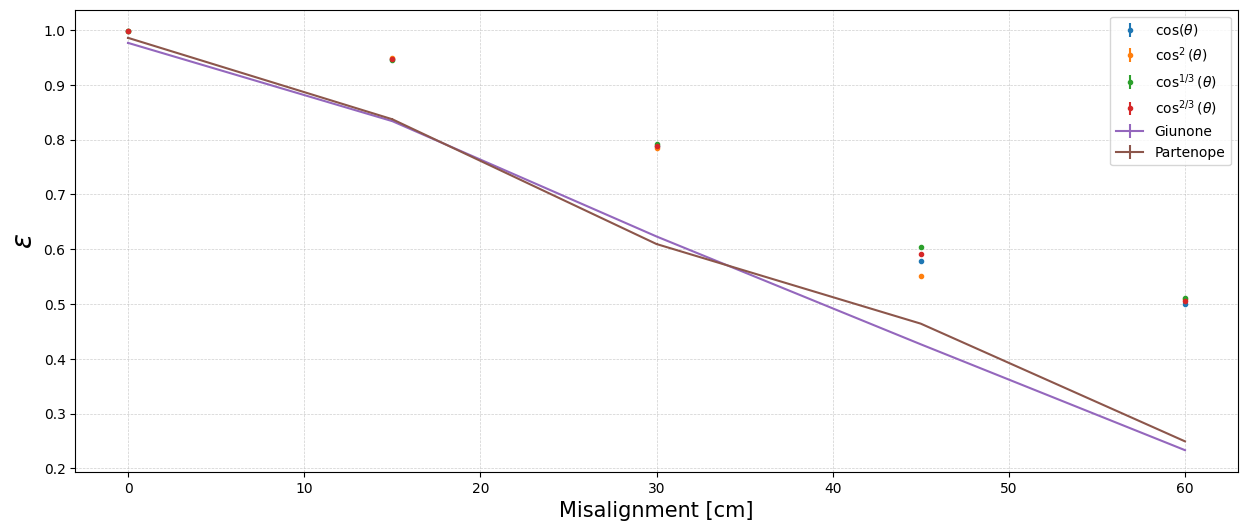

In [ ]:
labels = {
    '': r'$\cos(\theta)$',
    's': r'$\cos^{2}(\theta)$',
    '1': r'$\cos^{1/3}(\theta)$',
    '2': r'$\cos^{2/3}(\theta)$'
}

frac = lambda a, b: propagazione_errore(
    ["a", "b"],
    "a/b",
    [a, b],
    [[np.sqrt(a), 0], [0, np.sqrt(b)]],
    Display=False
)

df_filtered = df_G[df_G[' pm_doppie'].notna()]

y_g = ( df_filtered[' pgm_triple'] / df_filtered[' pm_doppie']).iloc[:5].values
err_g = np.array([
    frac(a, b)
    for a, b in zip(df_filtered[' pgm_triple'][:5],
                    df_filtered[' pm_doppie'][:5])
])

df_filtered = df_P[df_P[' gm_doppie'].notna()]
y_p = [pair[1] / pair[0] for pair in partenope]
err_p =  np.array([
    frac(a, b)
    for a, b in zip(df_P[' pgm_triple'][:5],
                    df_P[' gm_doppie'][:5])
])

x = np.linspace( 0, 60, 5)

plt.figure(figsize= (15,6))
for key in ['', 's', '1', '2']:
    y = [results[t][key] for t in x]
    err_y = [errors[t][key] for t in x]
    plt.errorbar(x, y, err_y, label=labels[key], fmt = '.')

plt.errorbar(x, y_g, err_g, label = 'Giunone', )
plt.errorbar(x, y_p, err_p, label = 'Partenope')
plt.ylabel(r'$ \epsilon $', fontsize = 20)
plt.xlabel('Misalignment [cm]', fontsize = 15)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6,)

# plt.savefig('pg_eff.pdf')

In [19]:
print (err_p)

[0.00208366555388779 0.00189750602808923 0.00163451572697396
 0.00135225668755810 0.00106429979385968]


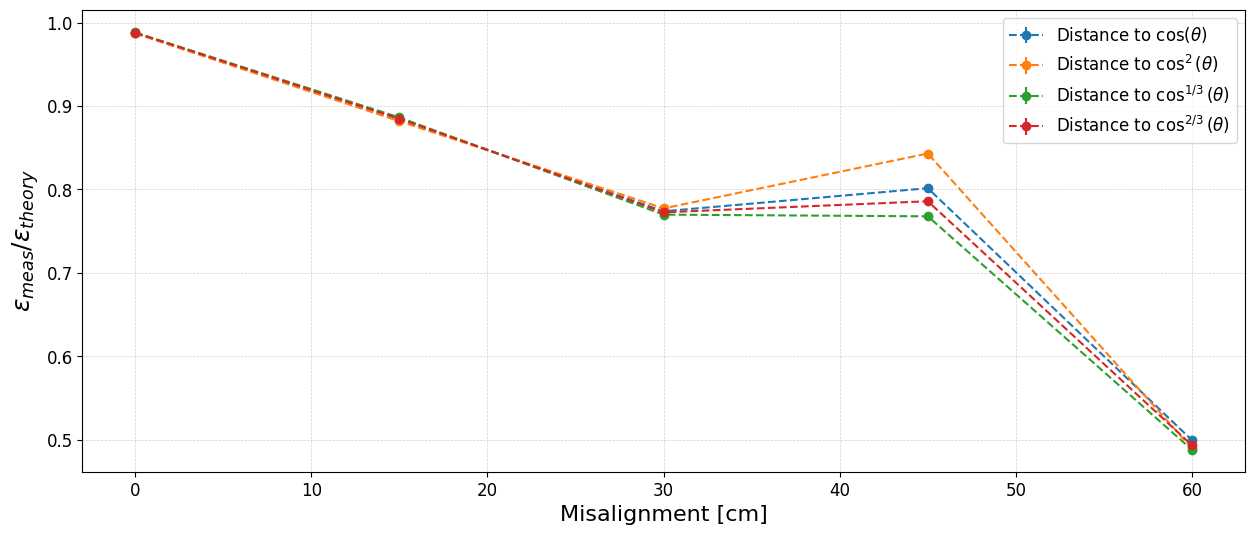

In [ ]:

plt.figure(figsize=(15, 6))

# Loop through each of the 4 theoretical models
for key in ['', 's', '1', '2']:
    # Convert ALL arrays to native numpy 64-bit floats to strip SymPy object wrappers
    y_model = np.array([results[t][key] for t in x], dtype=np.float64)
    sigma_model = np.array([errors[t][key] for t in x], dtype=np.float64)
    y_experimental = np.array(y_p, dtype=np.float64)
    err_p_numeric = np.array(err_p, dtype=np.float64)
    
    # Calculate (Experimental - Model) / Sigma safely
    normalized_distance = (y_experimental /y_model)#/ np.sqrt(sigma_model**2 + err_p_numeric**2))
    
    # Plot the normalized distances as points connected by a dashed line
    plt.errorbar(x, normalized_distance, np.sqrt(sigma_model**2 + err_p_numeric**2), marker='o', linestyle='--', label=f"Distance to {labels[key]}")

# --- STYLING THE PLOT ---
plt.ylabel(r'$\epsilon_{meas} / \epsilon_{theory}$', fontsize=18)
plt.xlabel('Misalignment [cm]', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Horizontal line at 0 set to dashed ('--') as requested
# plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Grid explicit configuration
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
plt.xlim(-3, 63)
plt.legend(loc='upper right', fontsize=12)

# plt.show()
# plt.savefig('p_eff_dist.pdf')